# Regularized Weighted CNN

- Keep the baseline `SimpleCNN` architecture
- Keep `F2` for checkpoint selection
- Use a slightly smaller `pos_weight`
- Add mild augmentation and stronger regularization
- Lower the learning rate and stop earlier to reduce overfitting


### 1. Import libraries

In [1]:
import sys
import os
import copy
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
)

from src.data.dataloader import get_dataloaders
from src.data.transform import get_train_transforms
from src.models.cnn_baseline import SimpleCNN
from src.training.trainer import train_one_epoch, validate_one_epoch

os.chdir(ROOT)
print(Path.cwd())


/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning


### 2. Use CUDA else MPS

In [2]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')


Using device: mps


### 3. Data, mild augmentation, softened class weighting, and optimizer

In [3]:
train_transform = get_train_transforms(image_size=224)

train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='data_new/splits/train.csv',
    val_csv='data_new/splits/val.csv',
    test_csv='data_new/splits/test.csv',
    image_dir='data_new/images/train',
    test_image_dir='data_new/images/test',
    batch_size=32,
    image_size=224,
    num_workers=0,
    transform_train=train_transform,
)

train_df = pd.read_csv('data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus = (train_df['label'] == 0).sum()

raw_pos_weight = num_nevus / num_melanoma
soft_pos_weight = min(raw_pos_weight, 4.0)
pos_weight = torch.tensor([soft_pos_weight], dtype=torch.float32).to(device)

print(f'Raw class-ratio pos_weight: {raw_pos_weight:.4f}')
print(f'Using softened pos_weight: {soft_pos_weight:.4f}')

model = SimpleCNN(dropout_rate=0.6).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

model_save_path = os.path.abspath('models/cnn_baseline_weighted_regularized.pth')
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)


Raw class-ratio pos_weight: 8.1117
Using softened pos_weight: 4.0000


### 4. Train model with validation F2 checkpointing

In [4]:
num_epochs = 30
early_stopping_patience = 4

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_f2s = []
val_f2s = []
learning_rates = []

best_val_f2 = -1.0
best_epoch = -1
epochs_without_improvement = 0
best_model_state = None

for epoch in range(num_epochs):
    current_lr = optimizer.param_groups[0]['lr']

    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)
    scheduler.step(val_metrics['f2'])

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])
    learning_rates.append(current_lr)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f}, Train F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}, Val F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_model_state = copy.deepcopy(model.state_dict())
        torch.save(best_model_state, model_save_path)
        print(f'Saved best model at epoch {best_epoch}')
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= early_stopping_patience:
        print(f'Early stopping triggered at epoch {epoch + 1}')
        break

print(f'Best validation F2: {best_val_f2:.4f} at epoch {best_epoch}')

if best_model_state is not None:
    model.load_state_dict(best_model_state)


Epoch [1/30] | LR: 0.000500 | Train Loss: 0.7622, Train Acc: 0.8005, Train F2: 0.3333 | Val Loss: 0.7859, Val Acc: 0.8547, Val F2: 0.3026
Saved best model at epoch 1


Epoch [2/30] | LR: 0.000500 | Train Loss: 0.6685, Train Acc: 0.8030, Train F2: 0.4488 | Val Loss: 0.6658, Val Acc: 0.7969, Val F2: 0.4946
Saved best model at epoch 2


Epoch [3/30] | LR: 0.000500 | Train Loss: 0.6494, Train Acc: 0.7979, Train F2: 0.4618 | Val Loss: 0.7345, Val Acc: 0.7564, Val F2: 0.4449


Epoch [4/30] | LR: 0.000500 | Train Loss: 0.6423, Train Acc: 0.7960, Train F2: 0.4744 | Val Loss: 0.7009, Val Acc: 0.7525, Val F2: 0.4917


Epoch [5/30] | LR: 0.000500 | Train Loss: 0.6137, Train Acc: 0.8019, Train F2: 0.5100 | Val Loss: 0.6598, Val Acc: 0.6991, Val F2: 0.5598
Saved best model at epoch 5


...

Epoch [7/30] | LR: 0.000500 | Train Loss: 0.5706, Train Acc: 0.8154, Train F2: 0.5581 | Val Loss: 0.5965, Val Acc: 0.7752, Val F2: 0.5959
Saved best model at epoch 7


Epoch [8/30] | LR: 0.000500 | Train Loss: 0.5737, Train Acc: 0.8264, Train F2: 0.5683 | Val Loss: 0.6114, Val Acc: 0.7347, Val F2: 0.5893


Epoch [9/30] | LR: 0.000500 | Train Loss: 0.5502, Train Acc: 0.8331, Train F2: 0.5838 | Val Loss: 0.6204, Val Acc: 0.8142, Val F2: 0.5560


Epoch [10/30] | LR: 0.000500 | Train Loss: 0.5517, Train Acc: 0.8383, Train F2: 0.5856 | Val Loss: 0.6105, Val Acc: 0.7890, Val F2: 0.5918


Epoch [11/30] | LR: 0.000250 | Train Loss: 0.5129, Train Acc: 0.8502, Train F2: 0.6019 | Val Loss: 0.5807, Val Acc: 0.8261, Val F2: 0.5685
Early stopping triggered at epoch 11
Best validation F2: 0.5959 at epoch 7


### 5. Plot curves

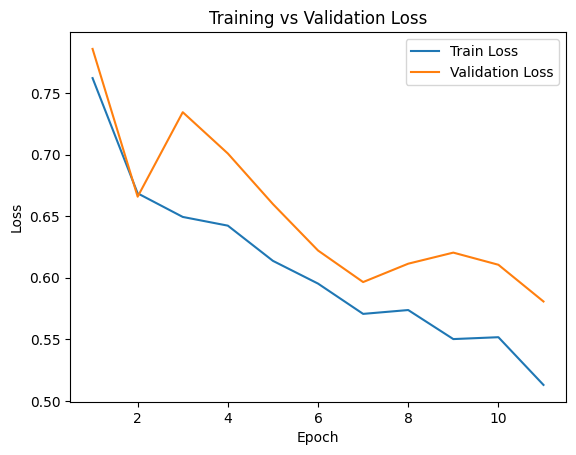

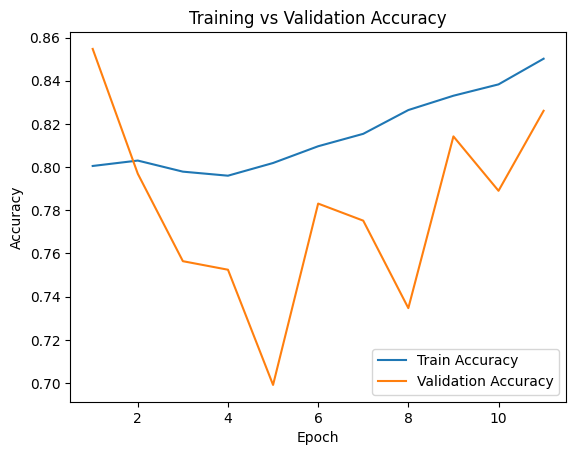

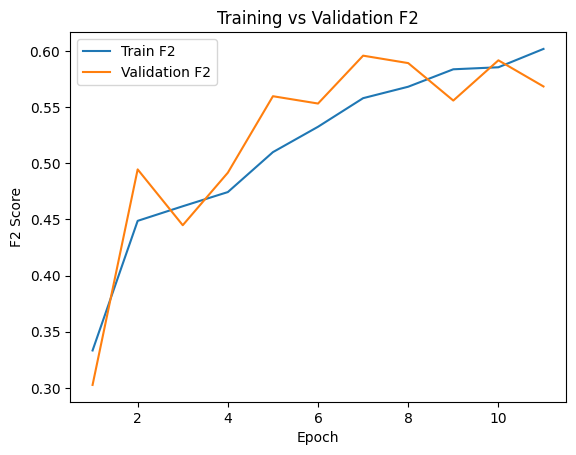

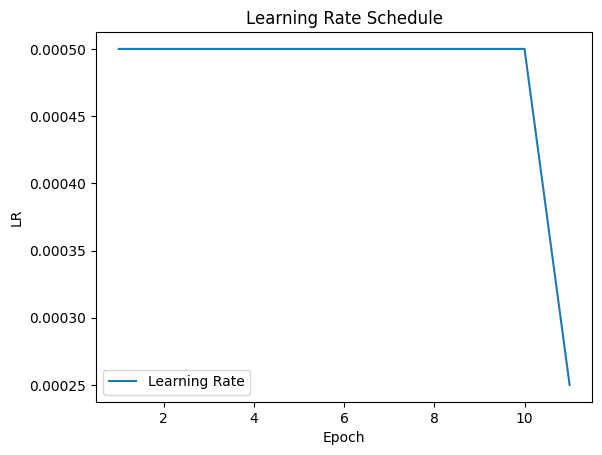

In [5]:
epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2')
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, learning_rates, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('LR')
plt.title('Learning Rate Schedule')
plt.legend()
plt.show()


### 6. Tune the threshold carefully on validation data

In [6]:
model.eval()

val_labels = []
val_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)

        val_labels.extend(labels.numpy())
        val_probs.extend(probs.cpu().numpy())

thresholds = np.arange(0.30, 0.81, 0.025)
precision_floor = 0.30

best_threshold = 0.5
best_f2 = -1
fallback_best_threshold = 0.5
fallback_best_f2 = -1

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in val_probs]
    precision = precision_score(val_labels, preds, zero_division=0)
    recall = recall_score(val_labels, preds, zero_division=0)
    f2 = fbeta_score(val_labels, preds, beta=2, zero_division=0)
    bal_acc = balanced_accuracy_score(val_labels, preds)

    print(
        f"Threshold={threshold:.3f} | "
        f"F2={f2:.4f} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"Balanced Acc={bal_acc:.4f}"
    )

    if f2 > fallback_best_f2:
        fallback_best_f2 = f2
        fallback_best_threshold = threshold

    if precision >= precision_floor and f2 > best_f2:
        best_f2 = f2
        best_threshold = threshold

if best_f2 < 0:
    best_threshold = fallback_best_threshold
    best_f2 = fallback_best_f2
    print(f"\nNo threshold met precision floor {precision_floor:.2f}; using best raw F2 threshold instead.")

print(f"\nSelected threshold on validation set: {best_threshold:.3f}")
print(f"Selected validation F2: {best_f2:.4f}")


Threshold=0.300 | F2=0.5879 | Precision=0.2396 | Recall=0.9237 | Balanced Acc=0.7684
Threshold=0.325 | F2=0.5923 | Precision=0.2468 | Recall=0.9110 | Balanced Acc=0.7721
Threshold=0.350 | F2=0.5881 | Precision=0.2482 | Recall=0.8941 | Balanced Acc=0.7683
Threshold=0.375 | F2=0.5877 | Precision=0.2534 | Recall=0.8771 | Balanced Acc=0.7680
Threshold=0.400 | F2=0.5858 | Precision=0.2590 | Recall=0.8559 | Balanced Acc=0.7663
Threshold=0.425 | F2=0.5926 | Precision=0.2707 | Recall=0.8432 | Balanced Acc=0.7717
Threshold=0.450 | F2=0.5962 | Precision=0.2840 | Recall=0.8220 | Balanced Acc=0.7743
Threshold=0.475 | F2=0.5942 | Precision=0.2947 | Recall=0.7966 | Balanced Acc=0.7725
Threshold=0.500 | F2=0.5959 | Precision=0.3122 | Recall=0.7712 | Balanced Acc=0.7735
Threshold=0.525 | F2=0.5898 | Precision=0.3277 | Recall=0.7373 | Balanced Acc=0.7688
Threshold=0.550 | F2=0.5708 | Precision=0.3411 | Recall=0.6864 | Balanced Acc=0.7557
Threshold=0.575 | F2=0.5490 | Precision=0.3555 | Recall=0.6356 | 

### 7. Evaluate best checkpoint on the test set

Confusion Matrix:
[[992 348]
 [ 40 131]]

              precision    recall  f1-score   support

           0     0.9612    0.7403    0.8364      1340
           1     0.2735    0.7661    0.4031       171

    accuracy                         0.7432      1511
   macro avg     0.6174    0.7532    0.6198      1511
weighted avg     0.8834    0.7432    0.7874      1511



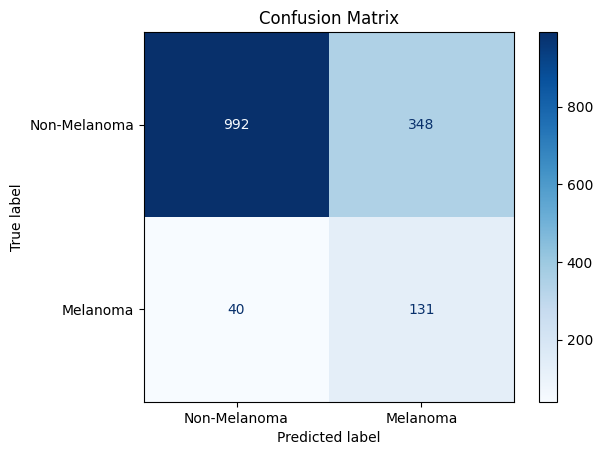

In [7]:
model = SimpleCNN(dropout_rate=0.6).to(device)
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

all_labels = []
all_probs = []
all_preds = []

threshold = best_threshold

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)
print()
print(classification_report(all_labels, all_preds, digits=4, zero_division=0))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


- The regularized weighted CNN improves on the previous improved baseline by combining a smaller positive-class weight, stronger dropout, higher weight decay, lower learning rate, and earlier stopping while still selecting checkpoints by validation F2. 
- This results in better generalization, with melanoma recall increasing to 76.61%, precision improving to 27.35%, and melanoma F1 rising to 0.4031. 
- The training curves still suggest mild overfitting, since training F2 continues to increase after validation F2 peaks at epoch 7, but the effect is weaker than in the previous run and is controlled by early stopping. 
- Overall, this model is a better recall-oriented compromise than 06, although it still does not surpass 02.cnn_baseline_weighted as the most balanced model overall.

| Model | Main Change | Accuracy | Melanoma Precision | Melanoma Recall | Melanoma F1 | Main Interpretation |
|---|---|---:|---:|---:|---:|---|
| `01.cnn_baseline` | Plain CNN with standard BCE loss | 0.8848 | 0.4848 | 0.2807 | 0.3556 | High overall accuracy, but poor melanoma detection due to class imbalance |
| `02.cnn_baseline_weighted` | Added `pos_weight` to BCE loss and tuned threshold by F1 | 0.8379 | 0.3706 | 0.6199 | 0.4639 | Best overall balance between melanoma detection and overall classification quality |
| `03.cnn_batchnorm_weighted` | Added BatchNorm to weighted CNN and tuned threshold by F2 | 0.7240 | 0.2560 | 0.7544 | 0.3822 | Higher recall, but much more aggressive and less balanced than `02` |
| `04.cnn_batchnorm_focalloss` | Replaced weighted BCE with focal loss and tuned threshold by F2 | 0.5850 | 0.2047 | 0.9240 | 0.3351 | Highest recall, but excessive false positives and weakest overall balance |
| `05.cnn_batchnorm_gap_augmented_weighted` | Added GAP head, stronger augmentation, weighted BCE, LR scheduling, and early stopping | 0.6161 | 0.2164 | 0.9123 | 0.3498 | Very high recall and fewer missed melanomas, but still too many false positives for a balanced model |
| `06.cnn_baseline_weighted_improved` | Softer `pos_weight`, F2 checkpointing, LR scheduling, early stopping, and finer threshold tuning | 0.7419 | 0.2635 | 0.7135 | 0.3849 | More controlled than the later recall-heavy models, with better balance but still below `02` overall |
| `07.cnn_baseline_weighted_regularized` | Lower `pos_weight`, stronger dropout, more weight decay, lower LR, mild augmentation, and earlier stopping | 0.7432 | 0.2735 | 0.7661 | 0.4031 | Best recall-oriented regularized CNN so far, with improved generalization and a better tradeoff than `06` |

### Summary

- `01.cnn_baseline` performs poorly for melanoma detection because it is biased toward the majority non-melanoma class.
- `02.cnn_baseline_weighted` gives the best overall tradeoff, improving melanoma recall substantially while maintaining the strongest melanoma F1 among all CNN variants tested.
- `03.cnn_batchnorm_weighted` improves recall further, but this comes with a clear drop in precision and accuracy.
- `04.cnn_batchnorm_focalloss` achieves the highest recall, but the large increase in false positives causes the worst precision and lowest overall accuracy.
- `05.cnn_batchnorm_gap_augmented_weighted` also achieves very high recall and misses few melanoma cases, but still sacrifices too much precision and overall balance compared with `02`.
- `06.cnn_baseline_weighted_improved` shows that softer weighting and better threshold tuning can reduce overly aggressive predictions.
- `07.cnn_baseline_weighted_regularized` improves further on `06` and is the strongest recall-oriented regularized CNN, but it still does not surpass `02` as the most balanced model.

### Conclusion

Among the seven CNN experiments, `02.cnn_baseline_weighted` remains the most balanced model overall. Although later variants such as `04`, `05`, and `07` achieve higher melanoma recall, they do so at the cost of more false positives, lower precision, and weaker overall balance. The results suggest that weighted BCE loss is more effective than focal loss for this task, and that regularization can improve recall-oriented models, but the simpler weighted baseline in `02` still provides the best practical tradeoff.
